<a href="https://colab.research.google.com/github/ehas1/Statistical-Bias-in-ML/blob/main/ExplanabilityGraphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

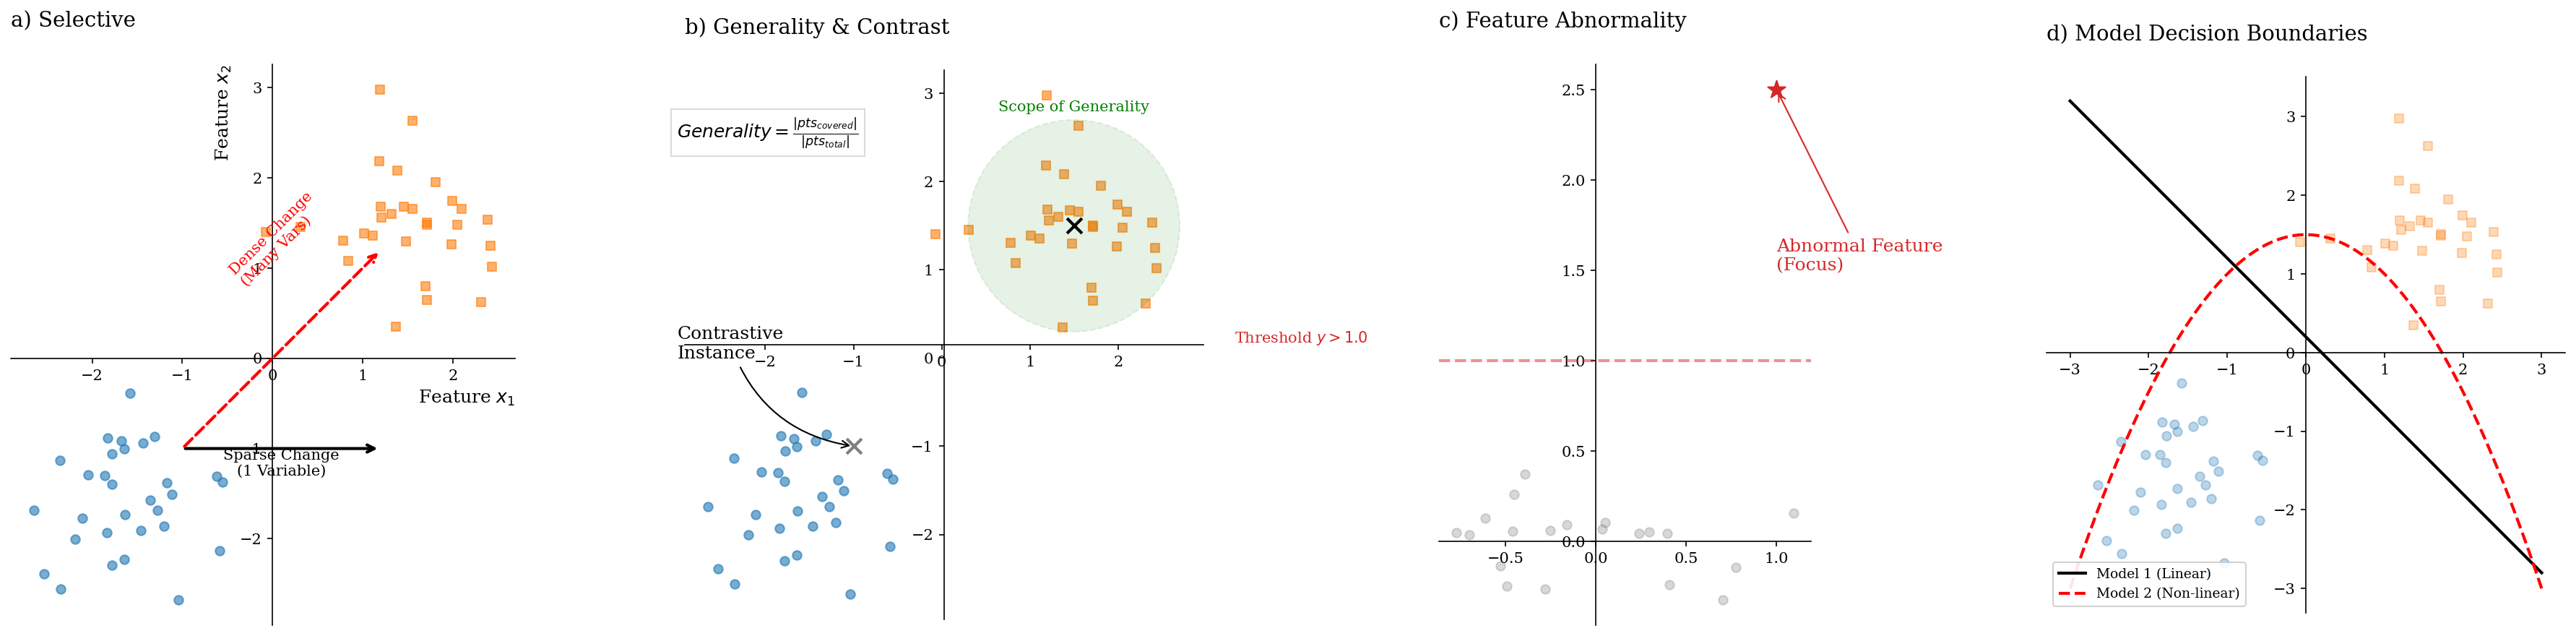

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# Set configuration for publication-quality plots
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',           # Times New Roman style for papers
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 2,
    'figure.autolayout': True,
    'text.usetex': False              # Set to True if you have a local LaTeX installation
})

# Data Generation Helpers
np.random.seed(42)
def generate_clusters(n=30):
    # Class 0
    x0 = np.random.normal(-1.5, 0.6, n)
    y0 = np.random.normal(-1.5, 0.6, n)
    # Class 1
    x1 = np.random.normal(1.5, 0.6, n)
    y1 = np.random.normal(1.5, 0.6, n)
    return x0, y0, x1, y1

# Initialize Figure (Changed to 1x4)
fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=150)
plt.subplots_adjust(wspace=0.3)

# Common Data
x0, y0, x1, y1 = generate_clusters()

# ========================================================
# Plot 1: Counterfactuals (Sparse vs Dense Changes)
# ========================================================
ax = axes[0]
ax.set_aspect('equal') # Fix aspect ratio
ax.scatter(x0, y0, c='#1f77b4', marker='o', alpha=0.6, label='Class A')
ax.scatter(x1, y1, c='#ff7f0e', marker='s', alpha=0.6, label='Class B')

# Remove top/right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

# Annotations representing vectors
# Vector 1: One variable change (Sparse)
ax.annotate('', xy=(1.2, -1.0), xytext=(-1.0, -1.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(0.1, -1.3, 'Sparse Change\n(1 Variable)', fontsize=10, ha='center')

# Vector 2: Many variable changes (Dense)
ax.annotate('', xy=(1.2, 1.2), xytext=(-1.0, -1.0),
            arrowprops=dict(arrowstyle='->', color='red', linestyle='--', lw=2))
ax.text(-0.5, 0.8, 'Dense Change\n(Many Vars)', color='red', fontsize=10, rotation=45)

ax.set_title("a) Selective", y=1.05, loc='left')
ax.set_xlabel("Feature $x_1$", loc='right')
ax.set_ylabel("Feature $x_2$", loc='top')


# ========================================================
# Plot 2: Generality & Contrastive Explanation
# ========================================================
ax = axes[1]
ax.set_aspect('equal') # Fix aspect ratio
ax.scatter(x0, y0, c='#1f77b4', marker='o', alpha=0.6)
ax.scatter(x1, y1, c='#ff7f0e', marker='s', alpha=0.6)

# Draw a "Region of Generality"
circle = patches.Circle((1.5, 1.5), radius=1.2, edgecolor='green', facecolor='green', alpha=0.1, linestyle='--')
ax.add_patch(circle)

# Specific points
ax.scatter(1.5, 1.5, c='black', marker='x', s=100, zorder=10) # Explained point
ax.scatter(-1.0, -1.0, c='gray', marker='x', s=100, zorder=10) # Contrast point

# Arrows
ax.annotate('Contrastive\nInstance', xy=(-1.0, -1.0), xytext=(-3, 0),
            arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=0.3", color='black'))

ax.text(1.5, 2.8, 'Scope of Generality', color='green', ha='center', fontsize=10)

# Equation text
equation = r"$Generality = \frac{|pts_{covered}|}{|pts_{total}|}$"
ax.text(-3, 2.5, equation, fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgray'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.set_title("b) Generality & Contrast", y=1.05, loc='left')


# ========================================================
# Plot 3 (Moved from 5): Focus / Abnormality
# ========================================================
ax = axes[2]
ax.set_aspect('equal') # Fix aspect ratio
# Normal data
ax.scatter(np.random.normal(0, 0.5, 20), np.random.normal(0, 0.2, 20), c='gray', alpha=0.3)

# Abnormal point
abnormal_x, abnormal_y = 1.0, 2.5
ax.scatter(abnormal_x, abnormal_y, c='#d62728', s=150, marker='*', label='Outlier')

# Dashed line indicating threshold
ax.axhline(y=1.0, color='#d62728', linestyle='--', alpha=0.5)
ax.text(-2, 1.1, 'Threshold $y > 1.0$', color='#d62728', fontsize=10)

ax.annotate('Abnormal Feature\n(Focus)', xy=(abnormal_x, abnormal_y), xytext=(1, 1.5),
            arrowprops=dict(arrowstyle='->', color='#d62728'), color='#d62728')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.set_title("c) Feature Abnormality", y=1.05, loc='left')


# ========================================================
# Plot 4 (Moved from 6): Model Decision Boundaries
# ========================================================
ax = axes[3]
ax.set_aspect('equal') # Fix aspect ratio
ax.scatter(x0, y0, c='#1f77b4', marker='o', alpha=0.3)
ax.scatter(x1, y1, c='#ff7f0e', marker='s', alpha=0.3)

# Grid range
xx = np.linspace(-3, 3, 100)

# Model 1: Simple Linear
yy_linear = -xx + 0.2
ax.plot(xx, yy_linear, color='black', label='Model 1 (Linear)', linewidth=2)

# Model 2: Complex / Non-linear
yy_complex = -0.5 * xx**2 + 1.5
ax.plot(xx, yy_complex, color='red', linestyle='--', label='Model 2 (Non-linear)', linewidth=2)

# Fix: Add legend and finish formatting
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.set_title("d) Model Decision Boundaries", y=1.05, loc='left')

plt.show()

In [ ]:
import pandas as pd

# 1. Load the dataset directly from the source
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-violent-parsed.csv"
df = pd.read_csv(url)

# 2. Create a helper function to format counts and percentages
def get_stats(data, column, value=None):
    if value:
        count = data[data[column] == value].shape[0]
    else:
        count = data.shape[0]

    total = len(data)
    percent = (count / total) * 100
    return f"{count:,}", f"{percent:.1f}%"

# 3. Calculate all statistics
stats = []

# Total
stats.append(["Total Observations", "All Rows", f"{len(df):,}", "100%"])

# Race
races = ['African-American', 'Caucasian', 'Hispanic', 'Other', 'Asian', 'Native American']
for race in races:
    count, pct = get_stats(df, 'race', race)
    stats.append(["Race", race, count, pct])

# Sex
for sex in ['Male', 'Female']:
    count, pct = get_stats(df, 'sex', sex)
    stats.append(["Sex", sex, count, pct])

# Priors (Numerical)
priors_mean = df['priors_count'].mean()
priors_median = df['priors_count'].median()
priors_min = df['priors_count'].min()
priors_max = df['priors_count'].max()

stats.append(["Criminal History", "Priors Count (Mean)", "-", f"{priors_mean:.2f}"])
stats.append(["Criminal History", "Priors Count (Median)", "-", f"{priors_median:.1f}"])
stats.append(["Criminal History", "Priors Count (Range)", "-", f"{priors_min} - {priors_max}"])

# Recidivism Outcomes
# Note: 'is_recid' = General Recidivism, 'is_violent_recid' = Violent Recidivism
recid_count = df[df['is_recid'] == 1].shape[0]
recid_pct = (recid_count / len(df)) * 100
stats.append(["Outcomes", "General Recidivism", f"{recid_count:,}", f"{recid_pct:.1f}%"])

v_recid_count = df[df['is_violent_recid'] == 1].shape[0]
v_recid_pct = (v_recid_count / len(df)) * 100
stats.append(["Outcomes", "Violent Recidivism", f"{v_recid_count:,}", f"{v_recid_pct:.1f}%"])

# 4. Create and display the final table
result_df = pd.DataFrame(stats, columns=["Variable", "Category / Metric", "Count (N)", "Percentage / Value"])

# Set 'Variable' as index for a cleaner look (optional)
# result_df.set_index("Variable", inplace=True)

print("Table 1: Descriptive Statistics of the COMPAS 'cox-violent-parsed' Dataset")
print("-" * 80)
print(result_df.to_string(index=False))

Table 1: Descriptive Statistics of the COMPAS 'cox-violent-parsed' Dataset
--------------------------------------------------------------------------------
          Variable     Category / Metric Count (N) Percentage / Value
Total Observations              All Rows    18,316               100%
              Race      African-American     9,791              53.5%
              Race             Caucasian     6,086              33.2%
              Race              Hispanic     1,451               7.9%
              Race                 Other       860               4.7%
              Race                 Asian        71               0.4%
              Race       Native American        57               0.3%
               Sex                  Male    14,933              81.5%
               Sex                Female     3,383              18.5%
  Criminal History   Priors Count (Mean)         -               3.91
  Criminal History Priors Count (Median)         -                2.0
  Cr